In [381]:
from cvxpy import *
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEBUG_ = False
import cProfile

In [382]:
    # A = np.array([[1,0.5,-0.125], [0, 1 , -0.5],[0, 0, 1]])
    # B = np.array([[-0.0208], [-0.125], [0.5]])
    #dt = 0.5
    # A = np.array([[1,0.1,-0.005], [0, 1 , -0.1],[0, 0, 1]])
    # B = np.array([[-0.0001667], [-0.005], [0.1]])
    #dt = 0.1
    # A = np.array([[1,1,-0.5],[0,1,-1],[0,1,1]])
    # B = np.array([[-0.1667],[-0.5],[1]])
    #dt = 1
    #A = np.array([[1,0.05,-0.00125], [0, 1 , -0.05],[0, 0, 1]])
    # B = np.array([[-0], [-0.00125], [0.05]])
    #dt = 0.5

In [383]:
def cvxpy_reverse(A, B, N, Q, R, P, x0, xr, umax=None, umin=None, xmin=None, xmax=None):
    f =  False
    (nx, nu) = B.shape

    # mpc calculation  x0 = distance, x1 = velocity, x2 = accel 
    x = cvxpy.Variable((nx, N + 1))
    u = cvxpy.Variable((nu, N))
    w1 = 1
    w2 = 0.5
    w3 = 0.2
    # w4 = 1.5

    costlist = 0.0
    constraints = []

    for t in range(N):
        costlist +=  (w1*((x[1, t]-xr[1])) + w2*(x[2, t]-xr[2]) + w3*((x[0, t]-xr[0]))) #(w1*((x[1, t]-xr[1]))**2 + w2*(x[2, t]-xr[2])**2 + w3*((x[0, t]-xr[0]))**2)
        costlist +=  0.5*u[:, t] # cvxpy.quad_form(u[:, t], R)
                # 0.5 * cvxpy.quad_form(u[:, t], R)

        constraints += [x[:, t + 1] == A * x[:, t] + B * u[:, t]]

        if xmin is not None:
            constraints += [x[:, t] >= xmin[:, 0]]
        if xmax is not None:
            constraints += [x[:, t] <= xmax[:, 0]]

    costlist += 0.5 *((x[1, N]-xr[1]) + (x[2, N]-xr[2]) + (x[0, N]-xr[0]))  # terminal cost #0.5 *((x[1, N]-xr[1])**2 + (x[2, N]-xr[2])**2 + (x[0, N]-xr[0])**2)  # terminal cost
    if xmin is not None:
        constraints += [x[:, N] >= xmin[:, 0]]
    if xmax is not None:
        constraints += [x[:, N] <= xmax[:, 0]]

    if umax is not None:
        constraints += [u <= umax]  # input constraints
    if umin is not None:
        constraints += [u >= umin]  # input constraints

    # print("this is inside functio",x0)

    constraints += [x[:, 0] == x0]  # inital state constraints

    prob = cvxpy.Problem(cvxpy.Minimize(costlist), constraints)

    prob.solve(solver=ECOS , warm_start=True) #solver= OSQP,
    if prob.status == 'optimal':
        f = True
    
    return f , x.value, u.value, costlist.value

In [384]:
def plotting(x_hist,u_hist,cost_hist,Xh,Xr,diff, DEBUG_=True):
    
    if DEBUG_:
        u_hist = np.array(u_hist).squeeze()
        cost_hist = np.array(cost_hist)

        # Plot the responses and cost
        plt.figure(figsize=(8, 8))
        plt.subplot(4, 1, 1)
        plt.plot(x_hist[:, 0], label='Dist')
        plt.plot(x_hist[:, 1], label='Velocity')

        plt.legend()
        plt.title('MPC Response')
        plt.ylabel('State')
        plt.grid()

        plt.subplot(4, 1, 2)
        plt.plot(u_hist, label='u')
        plt.legend()
        plt.ylabel('Input')
        plt.grid()

        plt.subplot(4, 1, 3)
        plt.plot(cost_hist, label=' Cost')
        plt.legend()
        plt.xlabel('Time')
        plt.ylabel('Cost')
        plt.grid()
        
        plt.subplot(4, 1, 4)
        plt.plot(Xh, label='Host distance')
        plt.plot(Xr, label='refernce distance')
        plt.legend()
        plt.ylabel('distance')
        plt.grid()
    

        # plt.figure(figsize=(8, 8))
        # plt.subplot(3, 1, 1)
        # plt.plot(diff, label='difference in distance')
        # plt.legend()
        # plt.ylabel('meters')
        # plt.grid()

        # plt.subplot(3, 1, 2)
        # plt.plot(x_hist[:, 2], label='accel')
        # plt.legend()
        # plt.ylabel('accel')
        # plt.grid()

        plt.show()

In [385]:
def reverse():
    print("start!! reverse ")
    A = np.array([[1,0.05,-0.00125], [0, 1 , -0.05],[0, 0, 1]])
    B = np.array([[-0], [-0.00125], [0.05]])
    # #dt = 0.05
    # A = np.array([[1,0.1,-0.005], [0, 1 , -0.1],[0, 0, 1]])
    # B = np.array([[-0.0001667], [-0.005], [0.1]])
    # # dt = 0.1

    (nx, nu) = B.shape

    Q = np.array([[100 , 10, 10],[10,10,10],[10,10,10]])
    R = np.eye(nu)*30
    P = np.eye(nx)*0.1

    x0 = np.array([100, 16.0, 0])  # initial state
    xr = np.array([8.0, 0 , 0]) # referance state 
    umax = 0.3
    umin = -0.5

    xmin = np.array([[3], [-50], [-4.5]])  # state constraints
    xmax = np.array([[600], [50.0],[3.0]])  # state constraints

    x_current = x0
    N = 15  # number of horizon
    nsim = 40
    x_hist = [x_current]
    u_hist = []
    cost_hist = []
    for i in range(nsim):
        f, x, u, c = cvxpy_reverse(A, B, N, Q, R, P, x0, xr, umax=umax, umin=umin, xmin=xmin, xmax=xmax)
        # print('Iteration:', i) #, 'Cost:', c, 'Input:', u[:,0])
        if  f :
            x0 = A.dot(x[:,0]) + B.dot(u[:,0]) #+ np.random.multivariate_normal(np.zeros(3), W)
            u_hist.append(u[:,0])
            x_hist.append(x0)
            cost_hist.append(c)
        else:
             print('No solution',i)
             break
           
    Xh = []
    Xr = [int(xr[0])]
    diff = []
    Vr = 0
    x_hist = np.array(x_hist)
    for k in range(1,len(x_hist[:,0])):
        Xr.append(Xr[k-1] + Vr*0.5)
        Xh.append( Xr[k] - x_hist[k,0])
        diff.append(-x_hist[k,0])
    

    print("aa")
    plotting(x_hist,u_hist,cost_hist,Xh,Xr,diff,True)
    
    return x_hist #cost_hist

In [386]:
def cvxpy_forward(A, B, N, R, x0, xr, umax=None, umin=None, xmin=None, xmax=None):
    f =  False
    (nx, nu) = B.shape

    # mpc calculation x0 = distance, x1 = velocity, x2 = accel  
    x = cvxpy.Variable((nx, N + 1))
    u = cvxpy.Variable((nu, N))
    w1 = 1
    w2 = 0.5
    w3 = 0.2

    costlist = 0.0
    constraints = []
    # print("this is size of xr" , xr.size)
    
    for t in range(N):
        costlist +=  (w3*((x[0, t])) + w2*(x[2, t]) +  w1*((x[1, t])) ) # -xr[t,2]
        costlist += 0.5*u[:, t] #0.05 * cvxpy.quad_form(u[:, t], R)

        constraints += [x[:, t + 1] == A * x[:, t] + B * u[:, t]]

        if xmin is not None:
            constraints += [x[:, t] >= xmin[:, 0]]
        if xmax is not None:
            constraints += [x[:, t] <= xmax[:, 0]]

    costlist +=  0.5 *((x[1, N]) + (x[2, N]) + (x[0, N])) #0.5* (((x[2, N]-xr[N,2])**2  + ((x[1, N]-xr[N,1]))**2))  # terminal cost ((x[0, t]- xr[t,0])/100)**2
    if xmin is not None:
        constraints += [x[:, N] >= xmin[:, 0]]
    if xmax is not None:
        constraints += [x[:, N] <= xmax[:, 0]]

    if umax is not None:
        constraints += [u <= umax]  # input constraints
    if umin is not None:
        constraints += [u >= umin]  # input constraints

    constraints += [x[:, 0] == x0]  # inital state constraints

    prob = cvxpy.Problem(cvxpy.Minimize(costlist), constraints)

    prob.solve(solver=ECOS , warm_start=True) #solver= OSQP,
    if prob.status == 'optimal':
        f = True
    
    return f , x.value, u.value, costlist.value

In [387]:
def forward(x_rev):
    print("start!! forward !!")
    A = np.array([[1,0.05,-0.00125], [0, 1 , -0.05],[0, 0, 1]])
    B = np.array([[-0], [-0.00125], [0.05]])
    #dt = 0.05
    (nx, nu) = B.shape
    
    # Q = np.array([[100 , 10, 10],[10,10,10],[10,10,10]])
    R = np.eye(nu)*0.5
    # P = np.eye(nx)*0.1

    x0 = np.array([100.0, 16.0, 0]) # initial state
    umax = 0.4
    umin = -0.8

    xmin = np.array([[3], [-50], [-4.5]])  # state constraints
    xmax = np.array([[600], [50.0],[3.0]])  # state constraints

    x_current = x0
    N = 15  # number of horizon
    nsim = 60
    x_hist = [x_current]
    u_hist = []
    cost_hist = []
    # run = min( (x_rev.size/3-15), nsim - N )  
    for i in range(int(x_rev.size/3) - N -1): #nsim -N-2  
        xr = x_rev[i:i+N,:]
        f, x, u, c = cvxpy_forward(A, B, N,R, x0, xr, umax=umax, umin=umin, xmin=xmin, xmax=xmax)
        # print('Iteration:', i) #, 'Cost:', c, 'Input:', u[:,0])
        if  f :
            x0 = A.dot(x[:,0]) + B.dot(u[:,0])
            u_hist.append(u[:,0])
            x_hist.append(x0)
            cost_hist.append(c)
        else:
             print('No solution',i)
             break
           

    print("aa")
    Xh = []
    Xr = [int(xr[0,0])]
    diff = []
    Vr = 0
    x_hist = np.array(x_hist)
    for k in range(1,len(x_hist[:,0])):
        Xr.append(Xr[k-1] + Vr*0.5)
        Xh.append( Xr[k] - x_hist[k,0])
        diff.append(-x_hist[k,0])

    plotting(x_hist,u_hist,cost_hist,Xh,Xr,diff,True)  

start!! reverse 
aa


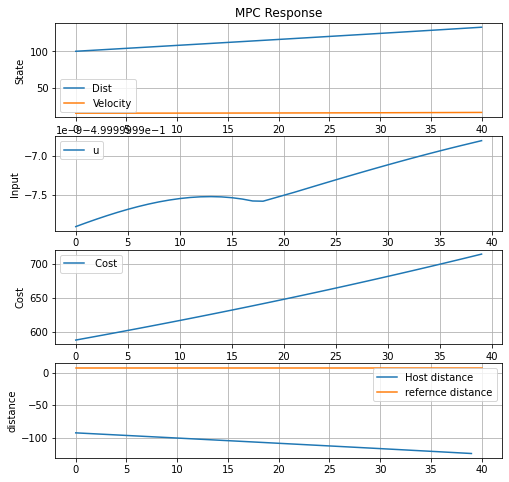

start!! forward !!
aa


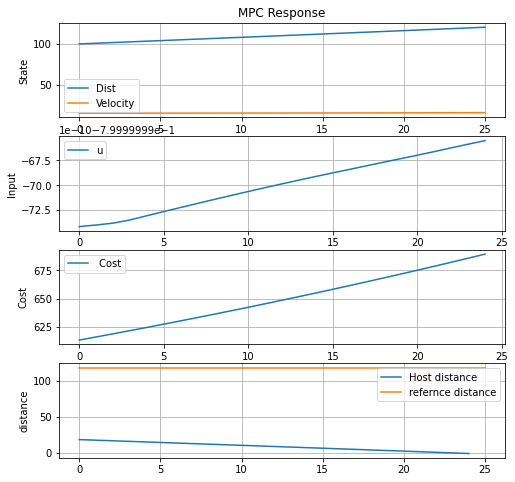

In [388]:
if __name__ == '__main__':
    DEBUG_ = False
    #x_rev = cProfile.run('reverse()')
    x_rev = reverse()
    # for k in range(1,len(x_rev[:,0])):
    # #print(x_rev[k,0])
    #     if 99 < x_rev[k,0] < 101:
    #         break
   
    forward(x_rev)